dataset: https://drive.google.com/file/d/1X5XhZ7PAvKYFgHv_JzeVNB-t4LfCDMDt/view

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('/content/AirPassengers.csv')

In [4]:
df

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121
...,...,...
139,1960-08,606
140,1960-09,508
141,1960-10,461
142,1960-11,390


In [5]:
#info, check null, duplicate

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Month        144 non-null    object
 1   #Passengers  144 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ KB


In [6]:
df.isnull().sum()

,0
Month,0
#Passengers,0


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df['Month'] = pd.to_datetime(df['Month'])

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Month        144 non-null    datetime64[ns]
 1   #Passengers  144 non-null    int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 2.4 KB


In [11]:
df.set_index('Month', inplace=True)

In [12]:
df

,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
...,...
1960-08-01,606
1960-09-01,508
1960-10-01,461


Figure(640x480)


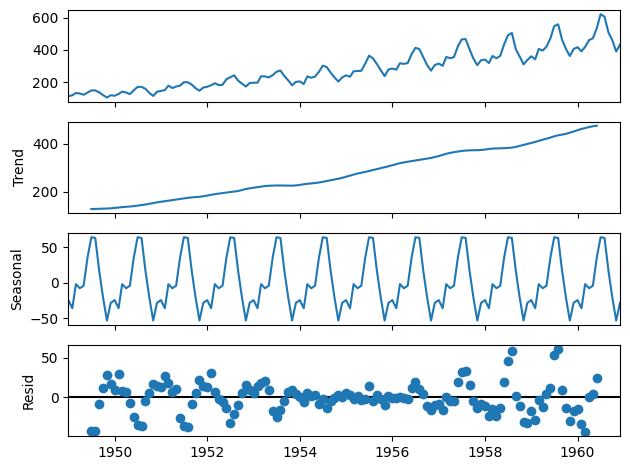

In [15]:
# Seasonal decomposition
# Trend
# Seasonality
# Residual

from statsmodels.tsa.seasonal import seasonal_decompose
decomposed = seasonal_decompose(df)
print(decomposed.plot())

In [16]:
# stationary data or not
# adf test


In [17]:
from statsmodels.tsa.stattools import adfuller

In [18]:
result = adfuller(df)

In [19]:
result


(np.float64(0.8153688792060498),
 np.float64(0.991880243437641),
 13,
 130,
 {'1%': np.float64(-3.4816817173418295),
  '5%': np.float64(-2.8840418343195267),
  '10%': np.float64(-2.578770059171598)},
 np.float64(996.692930839019))

In [20]:
pval = result[1]

In [21]:
if pval > 0.05:
  print("Data is not sationary")
else :
  print("Data is Stationary ")

Data is not sationary


In [22]:
# Log transformation : To make the data stationary

first_log = np.log(df)

In [23]:
first_log

,#Passengers
Month,
1949-01-01,4.718499
1949-02-01,4.770685
1949-03-01,4.882802
1949-04-01,4.859812
1949-05-01,4.795791
...,...
1960-08-01,6.406880
1960-09-01,6.230481
1960-10-01,6.133398


<Axes: xlabel='Month'>

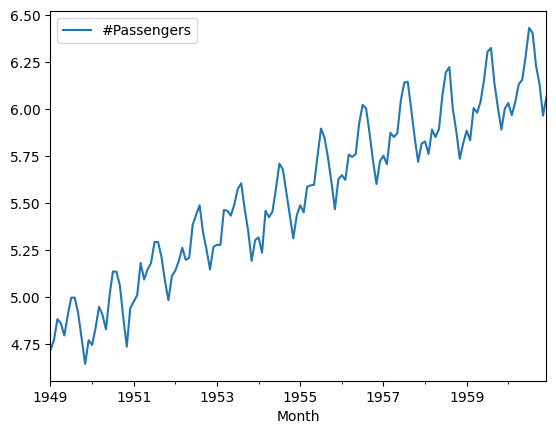

In [24]:
first_log.plot()

In [25]:
result = adfuller(first_log)

In [26]:
result[1]

np.float64(0.4223667747703874)

In [27]:
mean_log = first_log.rolling(window =12 ).mean()

In [28]:
mean_log

,#Passengers
Month,
1949-01-01,NaN
1949-02-01,NaN
1949-03-01,NaN
1949-04-01,NaN
1949-05-01,NaN
...,...
1960-08-01,6.124517
1960-09-01,6.132246
1960-10-01,6.142628


In [29]:
# First_log - mean_log
# log + rolling + difference

In [30]:
new_data = first_log - mean_log

In [31]:
new_data

,#Passengers
Month,
1949-01-01,NaN
1949-02-01,NaN
1949-03-01,NaN
1949-04-01,NaN
1949-05-01,NaN
...,...
1960-08-01,0.282363
1960-09-01,0.098235
1960-10-01,-0.009230


In [32]:
new_data.dropna(inplace= True)

In [33]:
new_data

,#Passengers
Month,
1949-12-01,-0.065494
1950-01-01,-0.093449
1950-02-01,-0.007566
1950-03-01,0.099416
1950-04-01,0.052142
...,...
1960-08-01,0.282363
1960-09-01,0.098235
1960-10-01,-0.009230


In [34]:
result = adfuller(new_data )

In [35]:
result[1]

np.float64(0.022234630001242206)

In [36]:
new_data

,#Passengers
Month,
1949-12-01,-0.065494
1950-01-01,-0.093449
1950-02-01,-0.007566
1950-03-01,0.099416
1950-04-01,0.052142
...,...
1960-08-01,0.282363
1960-09-01,0.098235
1960-10-01,-0.009230


In [37]:
train = new_data[:120]
test = new_data[120:]

In [38]:
train

,#Passengers
Month,
1949-12-01,-0.065494
1950-01-01,-0.093449
1950-02-01,-0.007566
1950-03-01,0.099416
1950-04-01,0.052142
...,...
1959-07-01,0.316430
1959-08-01,0.327838
1959-09-01,0.128057


In [39]:
 # ARIMA
 # P , D, Q
 # P => AR
 # Q => MA
 # D => Differencing, d=1

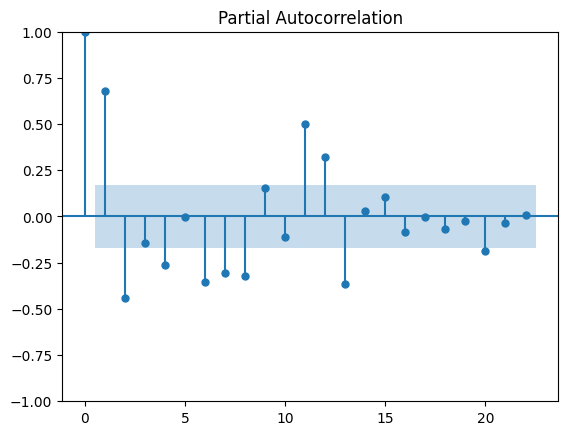

In [41]:
# PACF => Pratial correlation factor

from statsmodels.graphics.tsaplots import plot_pacf
plot_pacf(new_data)
plt.show()

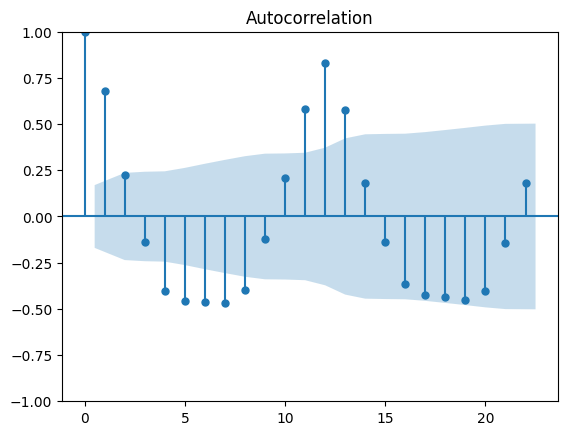

In [44]:
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(new_data)
plt.show()

In [45]:
from statsmodels.tsa.arima.model import ARIMA

In [46]:
A_MODEL = ARIMA(train,order=(11,1,7))


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [47]:
A_MODEL = A_MODEL.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [49]:
 new_data['ARIMAPREDICTION'] = A_MODEL.predict(start = len(train), end = len(train) + len(test) - 1)

In [50]:
new_data

,#Passengers,ARIMAPREDICTION
Month,,
1949-12-01,-0.065494,NaN
1950-01-01,-0.093449,NaN
1950-02-01,-0.007566,NaN
1950-03-01,0.099416,NaN
1950-04-01,0.052142,NaN
...,...,...
1960-08-01,0.282363,0.305526
1960-09-01,0.098235,0.128727
1960-10-01,-0.009230,-0.007992


<Axes: xlabel='Month'>

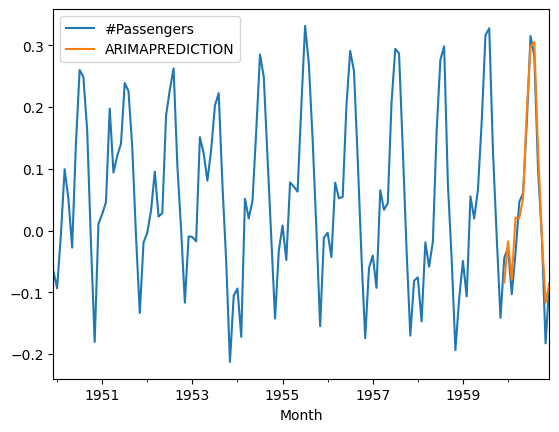

In [51]:
new_data[['#Passengers','ARIMAPREDICTION']].plot()